# Reading and writing data to the ALS BL.5.3.1 Tiled server
awojdyla@lbl.gov, sdeleon@lbl.gov, November 2025

We are using [Tiled](https://blueskyproject.io/tiled/) to read and write data from the ALS beamline 5.3.1. Tiled server (there will be a general ALS Tiled server.)

Tiled is part of [bluesky](https://blueskyproject.io/) data acquisition suite, and allows to read and write data remotely. Being part of bluesky makes it much easier to organize the data – each experimental run has a unique id, that can be used to retrieve the data later (or e.g. if you have a jupyter notebook running an experiment, you can retrieve the data even when the notebook is cold/not connected to the instruments.)

You need to be on the LBNL network (or use the VPN)
The process is explained here: [http://131.243.80.226:8000/](http://131.243.80.226:8000/)

To be able to write data, you will need to have the API key, which should be shared by your collaborator (ask Seij or Antoine.) Generally, it's recommended to use snap pass to share passwords https://snappass.lbl.gov/

In [1]:
#/usr/bin/env python3
#/opt/anaconda3/bin/envs
#!/opt/anaconda3/bin/python3

In [2]:
from tiled.client import from_uri
client = from_uri("http://131.243.80.226:8000")

## Navigating the data
https://blueskyproject.io/tiled/tutorials/navigation.html

In [3]:
from tiled.utils import tree
tree(client)

├── ee3bb3c3-d923-440d-926f-128b807a63ae
│   └── primary
│       └── internal
├── 85012139-5f28-442c-b5b6-3c159713507d
│   └── primary
│       ├── internal
│       └── det_image
├── f108671d-1c7c-4ce8-b196-687fce340960
├── becef540-3207-478a-9aa8-bfccc2f7a0f0
│   └── primary
│       └── internal
├── 6891b1f4-2fca-49cf-82e9-cf7762513493
│   └── primary
│       └── internal
├── 7ff76676-19bc-44a3-8430-fe16dfc7f5ea
│   └── primary
│       └── internal
├── cb2ff4d2-189b-47fc-93fc-7c182d1b7480
│   └── primary
│       └── internal
<Output truncated at 20 lines. Adjust tree's max_lines parameter to see more.>


In [4]:
# Get the last 20 runs
last_20_runs = client.values().tail(20)


In [5]:
last_20_runs[0].uri

'http://131.243.80.226:8000/api/v1/metadata/42b45eea-5f10-4396-88d7-5a6464eae7e7'

## Select a specific dataset

In [6]:
from tiled.client import from_uri
client = from_uri("http://131.243.80.226:8000")
db = client['7659a213-a284-494b-ae83-2fe9469c3cfe']['primary'].base['internal']

Text(0, 0.5, 'Diode Counts')

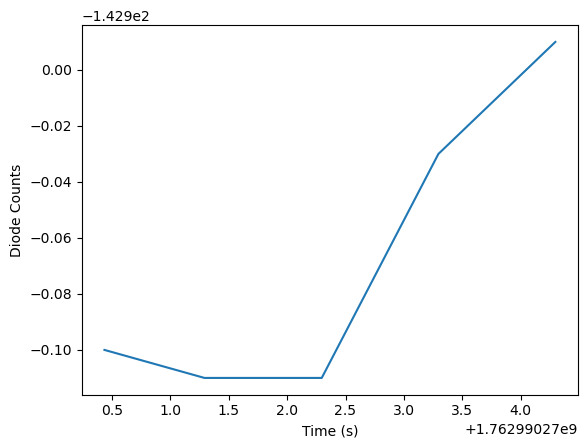

In [7]:
from matplotlib import pyplot as plt
counts = db.read()['diode']
time = db.read()['time']
plt.plot(time, counts)
plt.xlabel('Time (s)')
plt.ylabel('Diode Counts')

In [8]:
db.read()

,seq_num,time,diode,ts_diode
0,1,1.762990e+09,-143.00,1.762990e+09
1,2,1.762990e+09,-143.01,1.762990e+09
2,3,1.762990e+09,-143.01,1.762990e+09
3,4,1.762990e+09,-142.93,1.762990e+09
4,5,1.762990e+09,-142.89,1.762990e+09


## Writing data to the Tiled server directly
https://blueskyproject.io/tiled/tutorials/writing.html

In [9]:
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")


if not api_key:
   raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
#from bluesky.callbacks.tiled_writer import TiledWriter


ValueError: TILED_SINGLE_USER_API_KEY environment variable is not set.

In [ ]:
from tiled.client import from_uri
#tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tiled_client = from_uri("http://131.243.80.226:8000/", api_key=api_key)

#from bluesky.callbacks.tiled_writer import TiledWriter
#tw = TiledWriter(tiled_client)
#RE.subscribe(tw)

db = tiled_client['7659a213-a284-494b-ae83-2fe9469c3cfe']['primary'].base['internal']
print(db.read())


   seq_num          time   diode      ts_diode
0        1  1.762990e+09 -143.00  1.762990e+09
1        2  1.762990e+09 -143.01  1.762990e+09
2        3  1.762990e+09 -143.01  1.762990e+09
3        4  1.762990e+09 -142.93  1.762990e+09
4        5  1.762990e+09 -142.89  1.762990e+09


In [ ]:
import numpy
tiled_client.write_array(numpy.array([4, 5, 6]), metadata={"color": "blue", "barcode": 11})

<ArrayClient shape=(3,) chunks=((3,)) dtype=int64>

In [ ]:
#last 1
data = tiled_client.values().tail(1)[0]

## Writing data to the Tiled server using bluesky RunEngine (preferred way)

In [ ]:
# # removed

# # tiled_server = SimpleTiledServer(readable_storage=[DETECTOR_STORAGE])
# # tiled_client = from_uri(tiled_server.uri)
# # tiled_writer = TiledWriter(tiled_client)

# ## added
# import os
# api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
# if not api_key:
#    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
# tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)

# from bluesky.callbacks.tiled_writer import TiledWriter
# tiled_writer = TiledWriter(tiled_client)

# def setup_re_env(db_type="default", root_dir="/default/path", method="tiled"):
#     RE = RunEngine({})
#     bec = best_effort.BestEffortCallback()
#     RE.subscribe(bec)
#     _ = make_dir_tree(datetime.now().year, base_path=root_dir)
#     if method.lower() == "tiled":
#         RE.subscribe(tiled_writer)
#         return {"RE": RE, "db": tiled_client, "bec": bec}
#     elif method.lower() == "databroker":
#         db = Broker.named(db_type)
#         db.reg.register_handler("HDF5", HDF5Handler, overwrite=True)
#         try:
#             databroker.assets.utils.install_sentinels(db.reg.config, version=1)
#         except Exception:
#             pass
#         RE.subscribe(db.insert)
#         return {"RE": RE, "db": db, "bec": bec, }
#     else:
#         raise ValueError("The method for data storage used is not supported")


# def register_handlers(db, handlers):
#     for handler_spec, handler_class in handlers.items():
#         db.reg.register_handler(handler_spec, handler_class, overwrite=True)


# env = setup_re_env(db_type="temp", root_dir="/tmp/blop/sim", method="tiled")
# globals().update(env)
# bec.disable_plots()

# RE(agent.learn(iterations=2, n=1))

In [ ]:
# auto plot 1D, 2D, 